In [3]:
import pandas as pd

from google.colab import files
uploaded = files.upload() # Cargar el archivo en la memoria temporal de google colab

#Carga Archivo
df = pd.read_csv('credit_risk_dataset.csv')

print(df.head())
print(df.info())






Saving credit_risk_dataset.csv to credit_risk_dataset.csv
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.5

In [4]:
print("---- Resumen de variables ----")
print(df.describe())

print("---- Descripción de variables con problemas ----")

outliers_mask = (df['person_age'] > 90) | (df['person_emp_length'] > 60) | (df['loan_percent_income'] > 0.7)

total_perturbados = len(df[outliers_mask])
porcentaje_afectado = (total_perturbados / len(df)) * 100

print(f"Total de filas con datos perturbadores: {total_perturbados}")
print(f"Porcentaje de la base afectada: {porcentaje_afectado:.4f}%")



# Investigando los registros con 0% de compromiso
zeros_income = df[df['loan_percent_income'] == 0]

print(f"Cantidad de registros con 0% de compromiso: {len(zeros_income)}")
print(f"Porcentaje sobre el total: {len(zeros_income)/len(df)*100:.4f}%")

# ¿Esos ceros están pagando o están en default?
print("\nDistribución de Loan Status para los 'Ceros':")
print(zeros_income['loan_status'].value_counts())

---- Resumen de variables ----
         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   29465.000000  32581.000000         32581.000000   
mean       11.011695      0.218164             0.170203   
std         3.240459      0.413006             0.106782   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000

In [5]:
print("---- Limpieza de datos ---- ")


# 1. Definimos el filtro para mantener solo lo que es lógico
# Mantenemos: Edad <= 90, Antigüedad <= 60, Compromiso > 0 y Compromiso <= 0.7

df_clean = df[
    (df['person_age'] <= 90) &
    (df['person_emp_length'] <= 60) &
    (df['loan_percent_income'] <= 0.7) &
    (df['loan_percent_income'] > 0)
    ].copy()


print(df_clean.describe())

# 2. Imputamos los nulos que quedan (Interest Rate) con la mediana
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median())

# 3. Verificamos el nuevo tamaño
print(f"Tamaño original: {len(df)}")
print(f"Tamaño después de limpieza: {len(df_clean)}")
print(f"Filas eliminadas: {len(df) - len(df_clean)}")


---- Limpieza de datos ---- 
         person_age  person_income  person_emp_length     loan_amnt  \
count  31661.000000   3.166100e+04       31661.000000  31661.000000   
mean      27.725498   6.622127e+04           4.782066   9659.953097   
std        6.197883   4.888980e+04           4.034282   6333.839845   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.945600e+04           2.000000   5000.000000   
50%       26.000000   5.600000e+04           4.000000   8000.000000   
75%       30.000000   8.000000e+04           7.000000  12500.000000   
max       84.000000   1.782000e+06          41.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   28616.000000  31661.000000         31661.000000   
mean       11.040683      0.215344             0.169485   
std         3.229644      0.411067             0.105808   
min         5.420000      0.000000             0.010000   
25%         7.900000      0.000000  

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# 1. Crear Variables Dummy
# Usamos drop_first=True para evitar la multicolinealidad (Multicollinearity trap)
df_final = pd.get_dummies(df_clean, drop_first=True)

# 2. Separar Variables Predictoras (X) y Objetivo (y)
X = df_final.drop('loan_status', axis=1)
y = df_final['loan_status']

# 3. Dividir en Entrenamiento (Train) y Prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Escalado de datos (Crucial para modelos lineales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Entrenar el Modelo
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train_scaled, y_train)

# 6. Evaluar
predicciones = modelo_log.predict(X_test_scaled)
print(classification_report(y_test, predicciones))


              precision    recall  f1-score   support

           0       0.88      0.95      0.92      4968
           1       0.76      0.55      0.64      1365

    accuracy                           0.86      6333
   macro avg       0.82      0.75      0.78      6333
weighted avg       0.86      0.86      0.86      6333



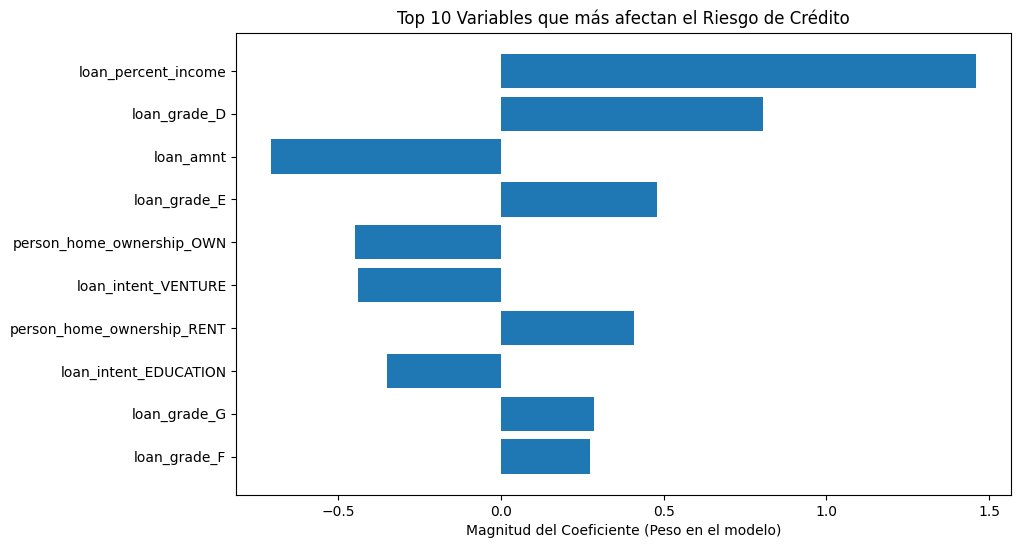

                       Variable  Coeficiente
5           loan_percent_income     1.459273
17                 loan_grade_D     0.806612
3                     loan_amnt    -0.703942
18                 loan_grade_E     0.479529
8     person_home_ownership_OWN    -0.446801
14          loan_intent_VENTURE    -0.438772
9    person_home_ownership_RENT     0.407937
10        loan_intent_EDUCATION    -0.348603
20                 loan_grade_G     0.285826
19                 loan_grade_F     0.273118
13         loan_intent_PERSONAL    -0.248134
4                 loan_int_rate     0.189055
16                 loan_grade_C     0.179950
1                 person_income     0.128927
15                 loan_grade_B     0.118084
2             person_emp_length    -0.049067
12          loan_intent_MEDICAL    -0.045955
0                    person_age    -0.029243
7   person_home_ownership_OTHER     0.021737
21  cb_person_default_on_file_Y     0.021328
11  loan_intent_HOMEIMPROVEMENT     0.018809
6    cb_pe

In [7]:
import matplotlib.pyplot as plt

# 1. Extraer coeficientes y nombres de columnas
importancias = modelo_log.coef_[0]
columnas = X.columns

# 2. Crear un DataFrame para visualizar mejor
df_importancia = pd.DataFrame({'Variable': columnas, 'Coeficiente': importancias})
df_importancia['Abs_Coef'] = df_importancia['Coeficiente'].abs()
df_importancia = df_importancia.sort_values(by='Abs_Coef', ascending=False)

# 3. Graficar
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Variable'][:10], df_importancia['Coeficiente'][:10])
plt.xlabel('Magnitud del Coeficiente (Peso en el modelo)')
plt.title('Top 10 Variables que más afectan el Riesgo de Crédito')
plt.gca().invert_yaxis()
plt.show()

print(df_importancia[['Variable', 'Coeficiente']])

In [8]:
import statsmodels.api as sm

# 1. Agregamos una columna de unos para el intercepto (beta_0)
X_train_sm = sm.add_constant(X_train_scaled)

# 2. Ajustamos el modelo (Logit)
# Nota: usamos los datos escalados para mantener la coherencia
modelo_sm = sm.Logit(y_train, X_train_sm).fit()

# 3. El "Summary" tipo R que tanto extrañabas
print(modelo_sm.summary())

Optimization terminated successfully.
         Current function value: 0.335327
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                25328
Model:                          Logit   Df Residuals:                    25305
Method:                           MLE   Df Model:                           22
Date:                Sat, 14 Mar 2026   Pseudo R-squ.:                  0.3562
Time:                        17:37:48   Log-Likelihood:                -8493.2
converged:                       True   LL-Null:                       -13193.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9509      0.025    -78.698      0.000      -1.999      -1.902
x1            -0.0296      0.

In [9]:
#---- MODEL FINAL REFINADO ----

# 1. Definimos la nueva lista de predictores (excluyendo solo las que decidimos quitar)
cols_to_drop = ['person_age', 'cb_person_cred_hist_length',
                'cb_person_default_on_file_Y', 'loan_intent_HOMEIMPROVEMENT']

X_opt = X.drop(columns=cols_to_drop)

# 2. Nuevo Split y Escalado
X_train_opt, X_test_opt, y_train, y_test = train_test_split(X_opt, y, test_size=0.2, random_state=42)

scaler_opt = StandardScaler()
X_train_opt_scaled = scaler_opt.fit_transform(X_train_opt)
X_test_opt_scaled = scaler_opt.transform(X_test_opt)

# 3. Entrenamiento Final
modelo_final = LogisticRegression(max_iter=1000)
modelo_final.fit(X_train_opt_scaled, y_train)

# 4. Evaluación Final
predicciones_final = modelo_final.predict(X_test_opt_scaled)
print("--- Classification Report (Modelo Optimizado) ---")
print(classification_report(y_test, predicciones_final))

--- Classification Report (Modelo Optimizado) ---
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      4968
           1       0.76      0.54      0.63      1365

    accuracy                           0.86      6333
   macro avg       0.82      0.75      0.77      6333
weighted avg       0.86      0.86      0.86      6333



In [13]:
# MODELO APLICADO A UN CLIENTE FICTICIO
import numpy as np
import pandas as pd

# 1. Creamos el perfil del cliente nuevo
# NOTA: Usamos exactamente las mismas columnas que X_opt
datos_cliente = {
'person_income': [45000],
    'person_emp_length': [2.0],
    'loan_amnt': [12000],
    'loan_int_rate': [12.5],
    'loan_percent_income': [0.27],
    'person_home_ownership_OTHER': [0],
    'person_home_ownership_OWN': [0],
    'person_home_ownership_RENT': [1],
    'loan_intent_EDUCATION': [0],
    'loan_intent_MEDICAL': [1], # La que decidimos conservar por criterio estadístico
    'loan_intent_PERSONAL': [0],
    'loan_intent_VENTURE': [0],
    'loan_grade_B': [0],
    'loan_grade_C': [1],
    'loan_grade_D': [0],
    'loan_grade_E': [0],
    'loan_grade_F': [0],
    'loan_grade_G': [0],
    'cb_person_default_on_file_N': [1]
}

# 2. Convertir a DataFrame asegurando el orden correcto de las columnas
nuevo_cliente = pd.DataFrame(datos_cliente)
nuevo_cliente = nuevo_cliente[X_opt.columns] # Reordenar según el entrenamiento

# 3. Escalar con el scaler que usamos en el modelo optimizado
nuevo_cliente_scaled = scaler_opt.transform(nuevo_cliente)

# 4. Obtener Predicción y Probabilidad
probabilidad = modelo_final.predict_proba(nuevo_cliente_scaled)[:, 1][0]
clase_predicha = modelo_final.predict(nuevo_cliente_scaled)[0]

# 5. Output Profesional
print("=== SISTEMA DE EVALUACIÓN DE RIESGO BANCARIO ===")
print(f"Probabilidad de Incumplimiento: {probabilidad:.2%}")
print(f"Resultado Automático: {'❌ RECHAZADO' if clase_predicha == 1 else '✅ APROBADO'}")
print("------------------------------------------------")

# Interpretación para el comité
if probabilidad > 0.20:
    print("Nota del Analista: Riesgo moderado/alto. Se recomienda revisión manual.")
else:
    print("Nota del Analista: Cliente dentro de los parámetros de bajo riesgo.")

=== SISTEMA DE EVALUACIÓN DE RIESGO BANCARIO ===
Probabilidad de Incumplimiento: 50.98%
Resultado Automático: ❌ RECHAZADO
------------------------------------------------
Nota del Analista: Riesgo moderado/alto. Se recomienda revisión manual.
